<a href="https://colab.research.google.com/github/N1HILO/Github-Activity/blob/main/Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 2: Data Preprocessing and Exploration**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pl
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv('https://github.com/justinn05/Phase-2/raw/refs/heads/main/spotify_data%20clean.csv')

In [ ]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)

# **1.1 Handle Missing Values**

In [ ]:
# Missing Values

missing_values = df.isnull().sum()
print('---------MISSING VALUES---------')
print(missing_values)

---------MISSING VALUES---------
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64


In [ ]:
#Fill missing artist names with unknown
df['artist_name'] = df['artist_name'].fillna('Unknown')

#Drop column that have 40-50% missing values
df.drop(columns=['artist_genres'], inplace=True)
missing_values = df.isnull().sum()

missing_values = df.isnull().sum()
print('---------(UPDATED)MISSING VALUES---------')
print(missing_values)

---------(UPDATED)MISSING VALUES---------
track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64


In [ ]:
# Dataset Preview

print('---------DATASET PREVIEW---------')
print(df.head(10))

---------DATASET PREVIEW---------
                 track_id                                       track_name  track_number  track_popularity  explicit     artist_name  artist_popularity  artist_followers                album_id                           album_name album_release_date  album_total_tracks album_type  track_duration_min
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)             4                 0      True           Diplo                 77           2812821  5QRFnGnBeMGePBKF2xTz5z                   d00mscrvll, Vol. 1         2025-10-31                   9      album                1.55
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!             1                 0      True        Yelawolf                 64           2363438  4SUmmwnv0xTjRcLdjczGg2                                 OMG!         2025-10-31                   1     single                3.07
2  7mdkjzoIYlf1rx9EtBpGmU                                      

# **1.2 Handle Outliers**

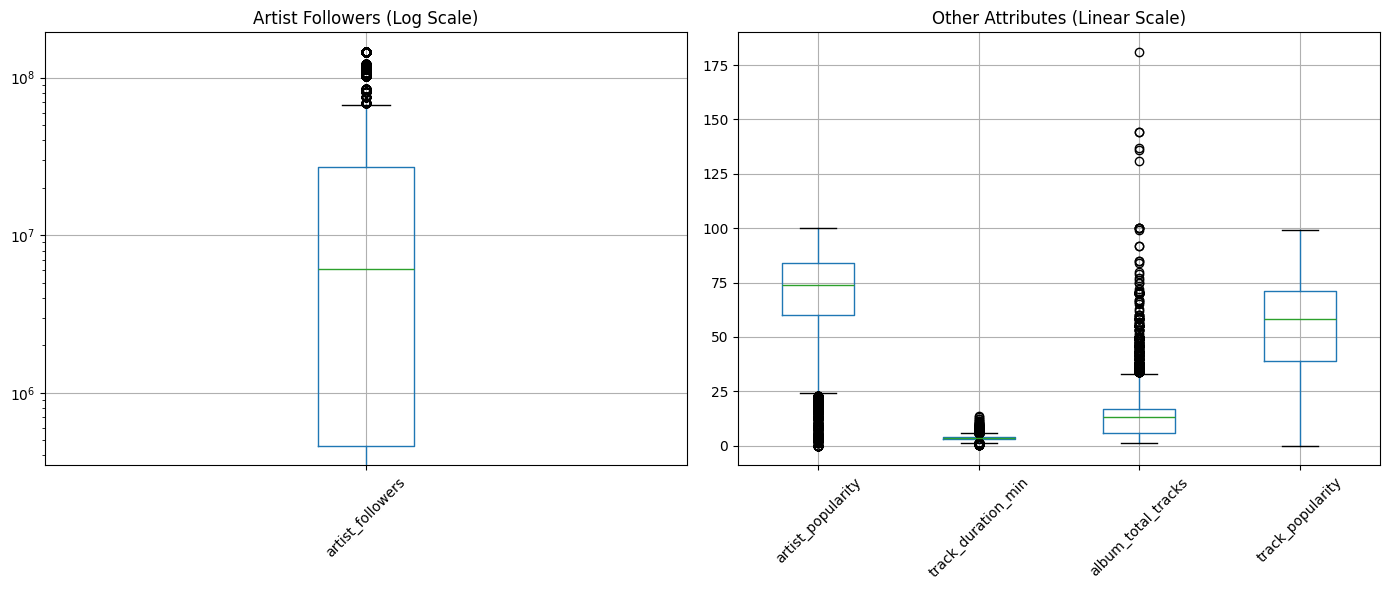

In [ ]:


log_col = ['artist_followers']
linear_cols = ['artist_popularity', 'track_duration_min', 'album_total_tracks', 'track_popularity']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Log Scale
df[log_col].boxplot(ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title("Artist Followers (Log Scale)")

# Plot 2: Linear Scale
df[linear_cols].boxplot(ax=axes[1])
axes[1].set_title("Other Attributes (Linear Scale)")

# --- THE FIX ---
# Rotate x-axis labels for both plots so they don't overlap
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

# Automatically adjust padding so labels fit nicely
plt.tight_layout()

plt.show()

### **Boxplot Interpretation**
1. Artist Followers           
Scale: Massive variance ($0$ to $145$ million).    
Insight: Most artists cluster around $6$ million followers, but a small group of "superstars" (outliers) exceed $100$ million, significantly skewing the average.
2. Artist Popularity (0–100)                                                   
Distribution: High concentration between $60$ and $84$ (Median: $74$).       
Insight: The dataset leans toward established artists. Low-end outliers ($0–30$) identify niche or emerging creators far below the mainstream norm.  
3. Track Duration (Min)    
Center: Most tracks are between $3$ and $4$ minutes.             
Outliers: Significant low-end outliers exist, including "micro-tracks" as short as $4$ seconds ($0.07$ min), likely representing interludes or intro snippets.
4. Album Total Tracks    
Standard: Typically ranges from $6$ to $17$ tracks.   
Outliers: Extreme high-end outliers (up to $181$ tracks) highlight the presence of massive box sets or compilation albums that deviate from standard release lengths.
5. Track Popularity (0–100)            
Distribution: Generally lower and more volatile than artist popularity (Median: $58$).
Insight: There is a "brand gap"—even popular artists have many individual tracks that perform significantly lower than their overall artist score.

In [ ]:

# 1. Handle Followers using Log Transformation
# (Good for 'Success' metrics where you want to keep the extremes but squish the scale)
df['artist_followers_log'] = np.log1p(df['artist_followers'])

# 2. Handle Duration using Capping (Winsorization)
# (Good for technical features where extreme values are likely noise or rare exceptions)
upper_limit = df['track_duration_min'].quantile(0.95)
df['track_duration_min'] = df['track_duration_min'].clip(upper=upper_limit)

# 3. Verify the change
print(f"Max Followers (Log): {df['artist_followers_log'].max():.2f}")
print(f"Max Track Duration (Capped): {df['track_duration_min'].max():.2f} minutes")

# Check the first few rows
df[['track_name', 'artist_followers_log', 'track_duration_min']].head()

Max Followers (Log): 18.80
Max Track Duration (Capped): 5.18 minutes


,track_name,artist_followers_log,track_duration_min
0,Trippy Mane (ft. Project Pat),14.849699,1.55
1,OMG!,14.675628,3.07
2,Hard 2 Find,12.172014,2.55
3,Still Get Like That (ft. Project Pat & Starrah),14.850015,1.69
4,ride me like a harley,9.069122,2.39


# **2.1 Data Transformation**

In [ ]:


# 1. Apply Z-score scaling (Standardization) to popularity and log-followers
# This centers the data around 0 with a standard deviation of 1
scaler_std = StandardScaler()
cols_to_std = ['artist_popularity', 'track_popularity', 'artist_followers_log']
df[cols_to_std] = scaler_std.fit_transform(df[cols_to_std])

# 2. Apply Min-Max scaling to duration and track counts
# This squishes the values into a strict range between 0 and 1
scaler_minmax = MinMaxScaler()
cols_to_minmax = ['track_duration_min']
df[cols_to_minmax] = scaler_minmax.fit_transform(df[cols_to_minmax])

# 3. Verify the transformation
print('---------NORMALIZED NUMERICAL FEATURES---------')
print(f"Mean of track_popularity: {df['track_popularity'].mean():.2f}")
print(f"Max of track_duration_min: {df['track_duration_min'].max():.2f}")
df[cols_to_std + cols_to_minmax].head()

---------NORMALIZED NUMERICAL FEATURES---------
Mean of track_popularity: -0.00
Max of track_duration_min: 1.00


,artist_popularity,track_popularity,artist_followers_log,track_duration_min
0,0.370071,-2.198484,0.023558,0.289628
1,-0.291681,-2.198484,-0.029937,0.587084
2,-1.106144,-2.030520,-0.799353,0.485323
3,0.370071,-0.938757,0.023655,0.317025
4,-1.106144,-2.198484,-1.752939,0.454012


# **2.2 Encode Categorical Features**

In [ ]:
# Convert 'explicit' to 0 or 1
df['explicit'] = df['explicit'].astype(int)

# Encode 'album_type' if it exists
if 'album_type' in df.columns:
    df = pd.get_dummies(df, columns=['album_type'], prefix='is', prefix_sep='_', dtype=int)

# Display results
print('---------ENCODED CATEGORICAL FEATURES---------')
print(f"Unique values in 'explicit': {df['explicit'].unique()}")

# Determine album type columns
album_cols = [col for col in ['is_album', 'is_single', 'is_compilation'] if col in df.columns]
if album_cols:
    print("\nAlbum Type Columns:")
    print(df[['explicit'] + album_cols].head(10))
else:
    print("\nAlbum type dummy columns not found.")

---------ENCODED CATEGORICAL FEATURES---------
Unique values in 'explicit': [1 0]

Album Type Columns:
   explicit  is_album  is_single  is_compilation
0         1         1          0               0
1         1         0          1               0
2         1         0          1               0
3         1         1          0               0
4         1         0          1               0
5         0         0          1               0
6         0         0          1               0
7         0         0          1               0
8         0         0          1               0
9         1         0          1               0


# **2.3 Feature Engineering**

In [ ]:
# 1. Create a "Popularity Ratio"
# Represents how popular a track is relative to the artist's overall fame
df['track_artist_ratio'] = df['track_popularity'] / (df['artist_popularity'] + 1e-6)

# 2. Create "Duration Category" (Binning)
# We bin tracks into Short, Medium, and Long based on track_duration_min
df['duration_type'] = pd.cut(df['track_duration_min'],
                            bins=3,
                            labels=['Short', 'Medium', 'Long'])

# 3. Convert the new category into dummy variables
# dtype=int ensures the columns contain 1 and 0 instead of True and False
df = pd.get_dummies(df, columns=['duration_type'], prefix='dur', dtype=int)

# 4. Create "is_collaboration" Flag
# 1 if "ft." or "feat" is in the track name, 0 otherwise
df['is_collaboration'] = df['track_name'].str.contains('ft.|feat', case=False).astype(int)

# 5. Create "release_month"
# Extracts the month (1-12) from the release date
df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
df['release_month'] = df['album_release_date'].dt.month.fillna(0).astype(int)

# 6. Final inspection
print('---------FEATURE ENGINEERING COMPLETE---------')
# Preview the whole sheet (all columns)
pd.set_option('display.max_columns', None)
print(df.head())

---------FEATURE ENGINEERING COMPLETE---------
                 track_id                                       track_name  track_number  track_popularity  explicit artist_name  artist_popularity  artist_followers                album_id                           album_name album_release_date  album_total_tracks  track_duration_min  artist_followers_log  is_album  is_compilation  is_single  track_artist_ratio  dur_Short  dur_Medium  dur_Long  is_collaboration  release_month
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)             4         -2.198484         1       Diplo           0.370071           2812821  5QRFnGnBeMGePBKF2xTz5z                   d00mscrvll, Vol. 1         2025-10-31                   9            0.289628              0.023558         1               0          0           -5.940693          1           0         0                 1             10
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!             1   

In [ ]:
# List of only the new features created during Feature Engineering
new_features = [
    'track_artist_ratio',
    'dur_Short',
    'dur_Medium',
    'dur_Long',
    'is_collaboration',
    'release_month'
]

# Display only these columns
print("--------- NEW FEATURES ONLY ---------")
print(df[new_features].head())

--------- NEW FEATURES ONLY ---------
   track_artist_ratio  dur_Short  dur_Medium  dur_Long  is_collaboration  release_month
0           -5.940693          1           0         0                 1             10
1            7.537326          0           1         0                 0             10
2            1.835676          0           1         0                 0             10
3           -2.536688          1           0         0                 1             10
4            1.987522          0           1         0                 0             10


# **Step 3: Data Reduction Methods**

In [ ]:
# Target: Top 50 hit classification
y = (df['track_popularity'] >= df['track_popularity'].nlargest(50).min()).astype(int)

# Drop non-numeric/leakage columns
X_num = df.drop(columns=['track_popularity', 'track_id', 'track_name',
                         'artist_name', 'album_id', 'album_name', 'album_release_date'])\
          .select_dtypes(include=['int64', 'float64', 'int32'])

# Standardize & apply PCA
X_scaled = StandardScaler().fit_transform(X_num)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Summary
print('--------- PCA REDUCTION COMPLETE ---------')
print(f"Original Features: {X_num.shape[1]} | Reduced Features: {X_pca.shape[1]}")

# Variance explained by each component
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTotal variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")


--------- PCA REDUCTION COMPLETE ---------
Original Features: 16 | Reduced Features: 11
PC1: 0.2521 (25.21%)
PC2: 0.1328 (13.28%)
PC3: 0.1173 (11.73%)
PC4: 0.0767 (7.67%)
PC5: 0.0706 (7.06%)
PC6: 0.0668 (6.68%)
PC7: 0.0622 (6.22%)
PC8: 0.0619 (6.19%)
PC9: 0.0519 (5.19%)
PC10: 0.0413 (4.13%)
PC11: 0.0269 (2.69%)

Total variance retained: 96.08%


In [ ]:
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

print(df_pca.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11
0 -0.513857 -2.493160  0.122350 -1.850274  5.166884  3.071059 -0.575078 -1.099338 -1.013758 -1.411226 -0.527852
1 -2.464992  0.400587  1.914808  0.243523  0.073255  0.956677  0.975400  0.063969  1.348468  0.061387 -0.345754
2 -3.239239  0.259218  1.326845  0.041995  0.054958  1.020514  0.687172 -0.500780  1.425792  0.238019  0.039759
3 -0.318241 -2.613561 -0.041328 -1.795649  5.089401  3.218231 -0.446398 -0.825636 -0.966375 -0.900184 -0.830720
4 -3.595147  0.164272  0.922477 -0.085156 -0.010493  1.150040  0.681192 -0.542640  1.496327  0.531480  0.270353


In [ ]:
#For saving the changes/ Kung gusto natin tignan changes or yung final output natin/ palagi dapat nasa last eto para reflect lahat ng changes/ pwede nyo rin tangalin muna eto tapos isave sa notepad nyo kung ayaw nyo palagi  na sasave
df.to_csv('spotify_data_updated.csv', index=False)

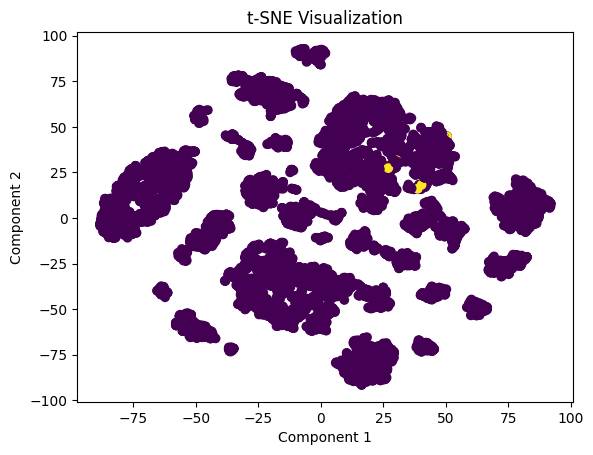

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('t-SNE Visualization')
plt.show()